# Iteration 1: Data Audit + Baseline

Goal: create the first reproducible baseline for the March Madness classification challenge.

This version uses `challenge_data_prep.py` for deterministic game pairing and safe baseline data assembly. The notebook stays focused on inspection, leakage review, and benchmark modeling.


In [50]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 27
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")


In [51]:
def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Challenge-1").exists():
            return candidate
    raise FileNotFoundError("Could not find the IS-455 project root from the current notebook location.")


PROJECT_ROOT = find_project_root(Path.cwd())
CHALLENGE_DIR = PROJECT_ROOT / "Challenge-1"
DATA_DIR = CHALLENGE_DIR / "data"
ML_KIT_DIR = PROJECT_ROOT / "ML-Pipeline-Kit"

for path in [CHALLENGE_DIR, ML_KIT_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

import challenge_data_prep as prep
import ml_library as ml

print(f"Project root: {PROJECT_ROOT}")
print(f"Challenge directory: {CHALLENGE_DIR}")
print(f"Data directory: {DATA_DIR}")


Project root: C:\Users\GeorgeColinRamsay\Documents\Github\IS-455
Challenge directory: C:\Users\GeorgeColinRamsay\Documents\Github\IS-455\Challenge-1
Data directory: C:\Users\GeorgeColinRamsay\Documents\Github\IS-455\Challenge-1\data


In [52]:
def choose_split(X: pd.DataFrame, y: pd.Series, groups: pd.Series | None = None) -> tuple[np.ndarray, np.ndarray, str]:
    index = np.arange(len(X))
    if groups is not None and pd.Series(groups).nunique(dropna=True) >= 5:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
        train_idx, test_idx = next(splitter.split(X, y, groups=groups))
        return np.asarray(train_idx), np.asarray(test_idx), "GroupShuffleSplit(test_size=0.20) by year"

    train_idx, test_idx = train_test_split(
        index,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE,
    )
    return np.asarray(train_idx), np.asarray(test_idx), "Stratified train_test_split(test_size=0.20)"


def choose_cv(y_train: pd.Series, groups_train: pd.Series | None = None):
    if groups_train is not None and pd.Series(groups_train).nunique(dropna=True) >= 3:
        n_splits = min(5, pd.Series(groups_train).nunique(dropna=True))
        return GroupKFold(n_splits=n_splits), f"GroupKFold({n_splits}) by year"

    min_class_count = int(pd.Series(y_train).value_counts().min())
    n_splits = min(5, min_class_count)
    if n_splits < 2:
        raise ValueError("Not enough observations per class for cross-validation.")
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE), f"StratifiedKFold({n_splits})"


def make_pipeline(feature_cols: list[str], estimator, scale_numeric: bool) -> Pipeline:
    numeric_steps: list[tuple[str, Any]] = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    preprocessor = ColumnTransformer(
        transformers=[("numeric", Pipeline(steps=numeric_steps), feature_cols)],
        remainder="drop",
    )
    return Pipeline(steps=[("preprocess", preprocessor), ("model", estimator)])


def evaluate_models(
    models: list[tuple[str, object, bool]],
    feature_cols: list[str],
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    groups_train: pd.Series | None = None,
) -> tuple[pd.DataFrame, dict[str, Pipeline], str]:
    cv, cv_name = choose_cv(y_train=y_train, groups_train=groups_train)
    fitted_models = {}
    rows = []

    for model_name, estimator, scale_numeric in models:
        pipeline = make_pipeline(feature_cols, estimator, scale_numeric=scale_numeric)
        try:
            if isinstance(cv, GroupKFold):
                cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, groups=groups_train, scoring="accuracy")
            else:
                cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy")

            pipeline.fit(X_train, y_train)
            fitted_models[model_name] = pipeline

            train_pred = pipeline.predict(X_train)
            test_pred = pipeline.predict(X_test)

            rows.append(
                {
                    "model": model_name,
                    "status": "ok",
                    "error": "",
                    "train_accuracy": accuracy_score(y_train, train_pred),
                    "cv_accuracy_mean": float(np.mean(cv_scores)),
                    "cv_accuracy_std": float(np.std(cv_scores)),
                    "test_accuracy": accuracy_score(y_test, test_pred),
                }
            )
        except Exception as exc:
            rows.append(
                {
                    "model": model_name,
                    "status": "failed",
                    "error": str(exc),
                    "train_accuracy": np.nan,
                    "cv_accuracy_mean": np.nan,
                    "cv_accuracy_std": np.nan,
                    "test_accuracy": np.nan,
                }
            )

    results = pd.DataFrame(rows)
    results["status_rank"] = (results["status"] != "ok").astype(int)
    results = results.sort_values(["status_rank", "test_accuracy", "cv_accuracy_mean"], ascending=[True, False, False]).drop(columns=["status_rank"]).reset_index(drop=True)
    return results, fitted_models, cv_name


In [53]:
bundle = prep.build_modeling_table(data_dir=DATA_DIR)
paired_games = bundle.modeling_table.copy()

print("Prepared table shapes:")
print(json.dumps({
    "team_features": bundle.merge_report["team_features_shape"],
    "matchup_rows": bundle.merge_report["matchup_rows_shape"],
    "modeling_table": bundle.merge_report["modeling_table_shape"],
}, indent=2))

print("Selected sources:")
display(pd.DataFrame(bundle.merge_report["team_feature_sources"]))

print("Location merge report:")
display(pd.DataFrame([bundle.merge_report["location_merge"]]))

display(paired_games.head())


Prepared table shapes:
{
  "team_features": [
    1087,
    150
  ],
  "matchup_rows": [
    2140,
    181
  ],
  "modeling_table": [
    2140,
    362
  ]
}
Selected sources:


,source_name,filename,prefix,rows,columns_added,coverage_pct
0,kenpom_barttorvik,KenPom Barttorvik.csv,kp,1147,95,100.0
1,teamrankings,TeamRankings.csv,tr,1147,38,100.0
2,resumes,Resumes.csv,res,1147,12,100.0


Location merge report:


,matchup_rows,location_rows_matched_pct,location_rows_missing
0,2140,99.67,7


,year,by_year_no,team_no,team,seed,round,current_round,score,game_index,slot_in_game,game_id,seed_num,loc_college_city,loc_college_state,loc_college_location,loc_college_time_zone,loc_college_time_zone_value,loc_college_daylight_savings_time,loc_college_latitude,loc_college_longitude,loc_game_city,loc_game_state,loc_game_location,loc_game_time_zone,loc_game_time_zone_value,loc_game_daylight_savings_time,loc_game_latitude,loc_game_longitude,loc_time_zone_combination,loc_direction,loc_latitude_diff,loc_longitude_diff,loc_time_zones_crossed,loc_time_zones_crossed_value,loc_distance_km,loc_distance_mi,kp_conf,kp_conf_id,kp_k_tempo,kp_k_tempo_rank,kp_kadj_t,kp_kadj_t_rank,kp_k_off,kp_ko_rank,kp_kadj_o,kp_kadj_o_rank,kp_k_def,kp_kd_rank,kp_kadj_d,kp_kadj_d_rank,kp_kadj_em,kp_kadj_em_rank,kp_badj_em,kp_badj_o,kp_badj_d,kp_barthag,kp_games,kp_w,kp_l,kp_win_pct,kp_efg_pct,kp_efg_pct_d,kp_ftr,kp_ftrd,kp_tov_pct,kp_tov_pct_d,kp_oreb_pct,kp_dreb_pct,kp_op_oreb_pct,kp_op_dreb_pct,kp_raw_t,kp_2pt_pct,kp_2pt_pct_d,kp_3pt_pct,kp_3pt_pct_d,kp_blk_pct,kp_blked_pct,kp_ast_pct,kp_op_ast_pct,kp_2ptr,kp_3ptr,kp_2ptrd,kp_3ptrd,kp_badj_t,kp_avg_hgt,kp_eff_hgt,kp_exp,kp_talent,kp_ft_pct,kp_op_ft_pct,kp_pppo,kp_pppd,kp_elite_sos,kp_wab,kp_badj_em_rank,kp_badj_o_rank,kp_badj_d_rank,kp_barthag_rank,kp_efg_pct_rank,kp_efgd_pct_rank,...,opp_kp_exp,opp_kp_talent,opp_kp_ft_pct,opp_kp_op_ft_pct,opp_kp_pppo,opp_kp_pppd,opp_kp_elite_sos,opp_kp_wab,opp_kp_badj_em_rank,opp_kp_badj_o_rank,opp_kp_badj_d_rank,opp_kp_barthag_rank,opp_kp_efg_pct_rank,opp_kp_efgd_pct_rank,opp_kp_ftr_rank,opp_kp_ftrd_rank,opp_kp_tov_pct_rank,opp_kp_tov_pct_d_rank,opp_kp_oreb_pct_rank,opp_kp_dreb_pct_rank,opp_kp_op_oreb_pct_rank,opp_kp_op_dreb_pct_rank,opp_kp_raw_t_rank,opp_kp_2pt_pct_rank,opp_kp_2pt_pct_d_rank,opp_kp_3pt_pct_rank,opp_kp_3pt_pct_d_rank,opp_kp_blk_pct_rank,opp_kp_blked_pct_rank,opp_kp_ast_pct_rank,opp_kp_op_ast_pct_rank,opp_kp_2ptr_rank,opp_kp_3ptr_rank,opp_kp_2ptrd_rank,opp_kp_3ptrd_rank,opp_kp_badjt_rank,opp_kp_avg_hgt_rank,opp_kp_eff_hgt_rank,opp_kp_exp_rank,opp_kp_talent_rank,opp_kp_ft_pct_rank,opp_kp_op_ft_pct_rank,opp_kp_pppo_rank,opp_kp_pppd_rank,opp_kp_elite_sos_rank,opp_tr_tr_rank,opp_tr_tr_rating,opp_tr_v_1_25_wins,opp_tr_v_1_25_loss,opp_tr_v_26_50_wins,opp_tr_v_26_50_loss,opp_tr_v_51_100_wins,opp_tr_v_51_100_loss,opp_tr_hi,opp_tr_lo,opp_tr_last,opp_tr_sos_rank,opp_tr_sos_rating,opp_tr_sos_hi,opp_tr_sos_lo,opp_tr_sos_last,opp_tr_luck_rank,opp_tr_luck_rating,opp_tr_luck_v_1_25_wins,opp_tr_luck_v_1_25_loss,opp_tr_luck_v_26_50_wins,opp_tr_luck_v_26_50_loss,opp_tr_luck_v_51_100_wins,opp_tr_luck_v_51_100_loss,opp_tr_luck_hi,opp_tr_luck_lo,opp_tr_luck_last,opp_tr_consistency_rank,opp_tr_consistency_tr_rating,opp_tr_consistency_v_1_25_wins,opp_tr_consistency_v_1_25_loss,opp_tr_consistency_v_26_50_wins,opp_tr_consistency_v_26_50_loss,opp_tr_consistency_v_51_100_wins,opp_tr_consistency_v_51_100_loss,opp_tr_consistency_hi,opp_tr_consistency_lo,opp_tr_consistency_last,opp_res_net_rpi,opp_res_resume,opp_res_wab_rank,opp_res_elo,opp_res_b_power,opp_res_q1_w,opp_res_q2_w,opp_res_q1_plus_q2_w,opp_res_q3_q4_l,opp_res_plus_500,opp_res_r_score,opp_res_bid_type,win,seed_diff,distance_mi_diff,distance_km_diff,time_zones_crossed_diff
0,2008,2,43,Kansas,1,1,2,75,0,0,2008_2_0,1,Lawrence,Kansas,Lawrence Kansas,Central,5.0,True,38.971669,-95.235250,San Antonio,Texas,San Antonio Texas,Central,5.0,True,29.42519,-98.494592,Central Central,West,-9.546478,-3.259342,0.0,0.0,1102.803342,685.250227,B12,7,68.8789,106,66.8546,88,117.530,1,121.433,1,89.3201,4,87.4681,3,33.9647,1,35.4,121.0,85.6,0.982,33,30,3,90.90909,56.3,44.8,37.5,30.8,18.7,22.9,38.0,71.0,29.0,62.0,69.0,54.8,40.9,39.9,34.0,17.7,6.5,62.8,53.5,70.8,29.2,61.9,38.1,69.5,77.100,81.427,2.047,89.633,70.8,67.7,1.173,0.891,30.290,9.9,1,1,3,1,5,19,...,1.605,82.995,59.6,67.3,1.121,0.853,20.888,8.9,3,24,1,2,50,4,113,93,13,64,24,42,42,24,60,24,7,170,7,10,102,148,39,234,109,316,26,50,34,71,201,11,340,86,19,1,111,3,28.7,3,1,3,0,9,0,3,20,3,45,14

## Leakage Review

The target already exists as `win` because the prep module paired opponents deterministically and compared team score to opponent score. The columns below are blocked from feature use in this iteration.


In [54]:
leakage_cols = bundle.merge_report["blocked_feature_columns"]
display(pd.DataFrame({"leakage_column": leakage_cols}))

label_balance = paired_games["win"].value_counts(normalize=True).rename("share").sort_index()
display(label_balance.to_frame())

preview_cols = [
    col
    for col in [
        "year",
        "current_round",
        "game_id",
        "team",
        "opp_team",
        "seed_num",
        "opp_seed_num",
        "seed_diff",
        "score",
        "opp_score",
        "win",
    ]
    if col in paired_games.columns
]
display(paired_games[preview_cols].head(12))


,leakage_column
0,round
1,current_round
2,score
3,opp_round
4,opp_current_round
5,opp_score


,share
win,
0,0.5
1,0.5


,year,current_round,game_id,team,opp_team,seed_num,opp_seed_num,seed_diff,score,opp_score,win
0,2008,2,2008_2_0,Kansas,Memphis,1,1,0,75,68,1
1,2008,2,2008_2_0,Memphis,Kansas,1,1,0,68,75,0
2,2008,4,2008_4_0,North Carolina,Kansas,1,1,0,66,84,0
3,2008,4,2008_4_0,Kansas,North Carolina,1,1,0,84,66,1
4,2008,4,2008_4_1,Memphis,UCLA,1,1,0,78,63,1
5,2008,4,2008_4_1,UCLA,Memphis,1,1,0,63,78,0
6,2008,8,2008_8_0,North Carolina,Louisville,1,3,-2,83,73,1
7,2008,8,2008_8_0,Louisville,North Carolina,3,1,2,73,83,0
8,2008,8,2008_8_1,Kansas,Davidson,1,10,-9,59,57,1
9,2008,8,2008_8_1,Davidson,Kansas,10,1,9,57,59,0


Baseline features: ['seed_num', 'opp_seed_num', 'seed_diff', 'year']


,seed_num,opp_seed_num,seed_diff,year,win
0,1,1,0,2008,1
1,1,1,0,2008,0
2,1,1,0,2008,0
3,1,1,0,2008,1
4,1,1,0,2008,1


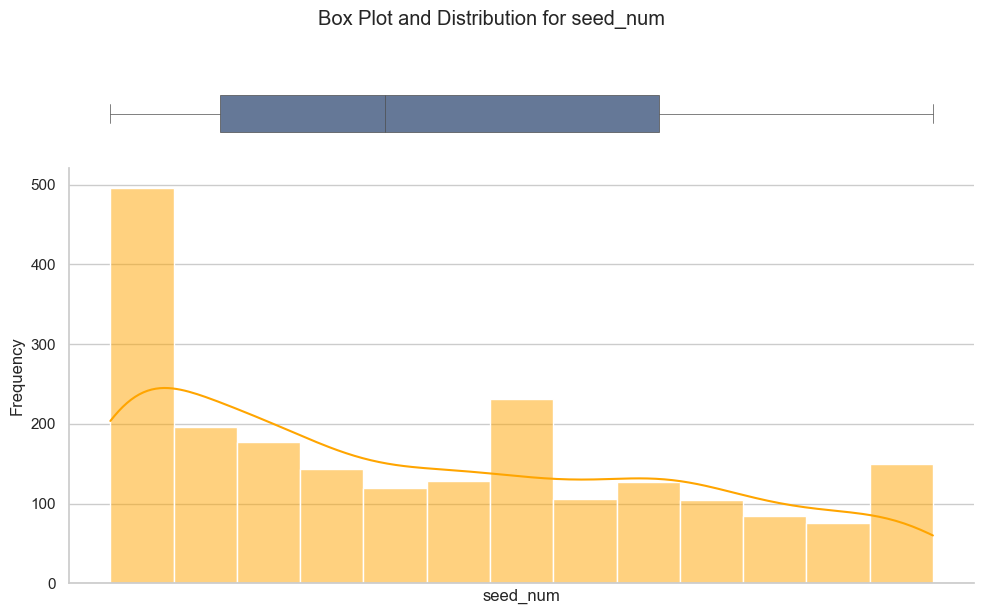

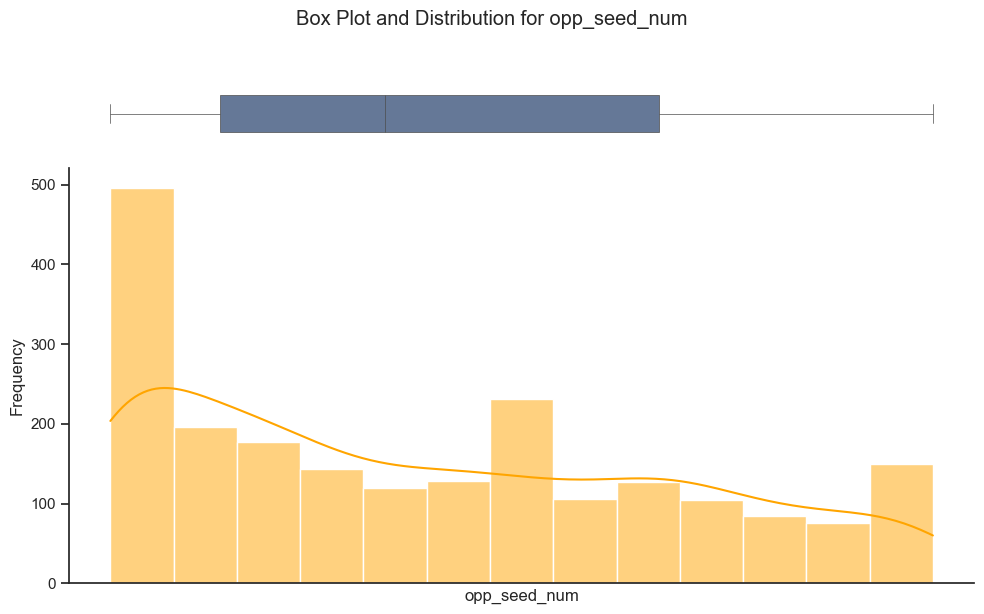

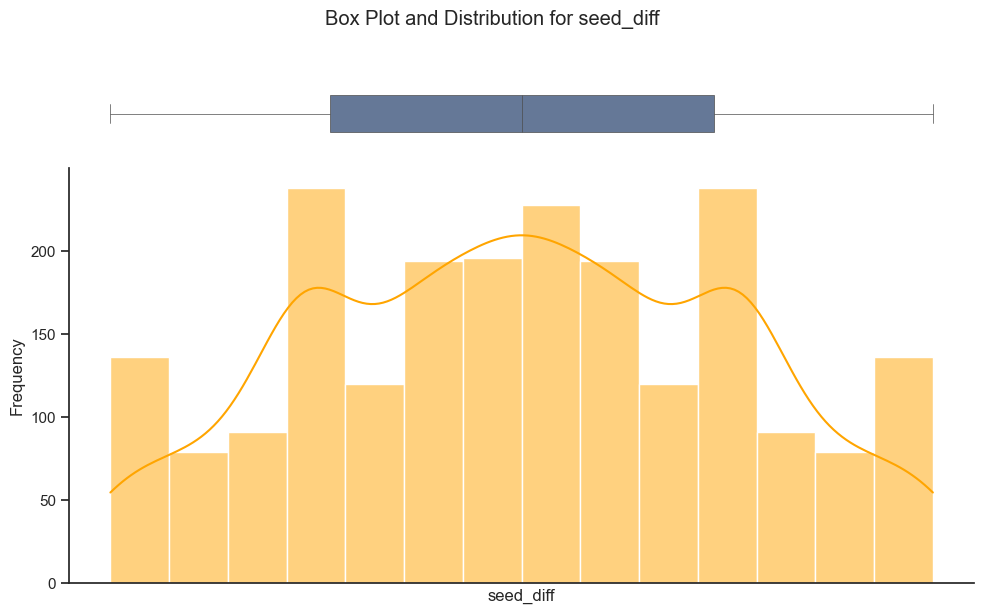

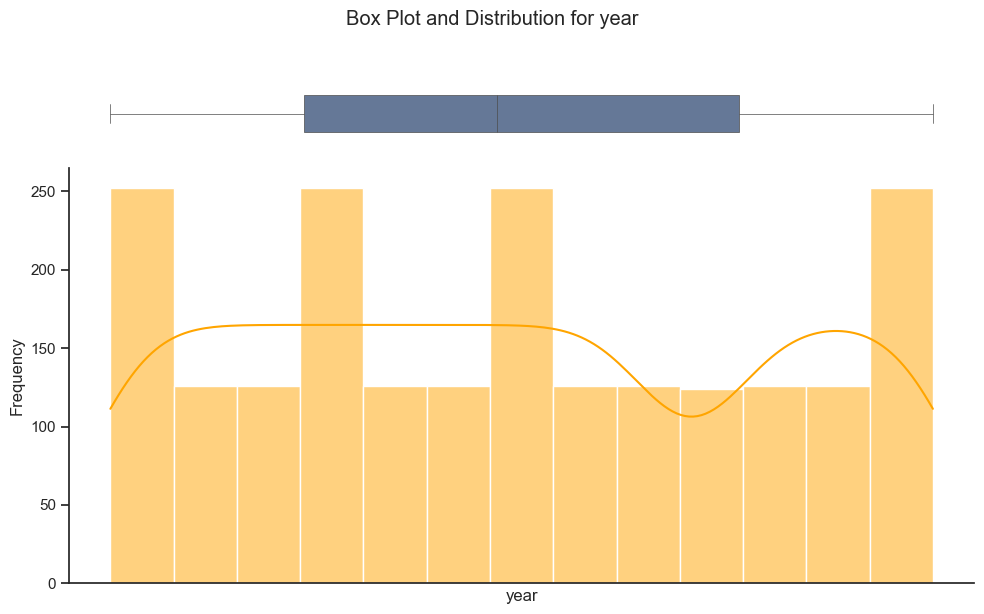

,Data Type,Count,Missing,Unique,Mode,Min,Q1,Median,Q3,Max,Mean,Std,Skew,Kurt
seed_num,int64,2140,0,16,1,1,3.0,6.0,11.0,16,6.778037,4.56359,0.419327,-1.041898
opp_seed_num,int64,2140,0,16,1,1,3.0,6.0,11.0,16,6.778037,4.56359,0.419327,-1.041898
seed_diff,int64,2140,0,29,-1,-15,-7.0,0.0,7.0,15,0.0,7.672041,0.0,-0.818427
year,int64,2140,0,17,2008,2008,2012.0,2016.0,2021.0,2025,2016.28972,5.26832,0.102046,-1.216896


In [55]:
candidate_baseline_features = [
    "seed_num",
    "opp_seed_num",
    "seed_diff",
    "year",
]
BASELINE_FEATURES = [col for col in candidate_baseline_features if col in paired_games.columns]

print("Baseline features:", BASELINE_FEATURES)
baseline_df = paired_games[BASELINE_FEATURES + ["win"]].copy()
display(baseline_df.head())
display(ml.univariate(baseline_df[BASELINE_FEATURES]))


In [56]:
X = paired_games[BASELINE_FEATURES].copy()
y = paired_games["win"].copy()
groups = paired_games["year"].copy() if "year" in paired_games.columns else None

train_idx, test_idx, split_name = choose_split(X, y, groups=groups)
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy() if isinstance(groups, pd.Series) else None

print(f"Split strategy: {split_name}")
print(f"Train size: {len(X_train):,}")
print(f"Test size: {len(X_test):,}")

models = [
    ("DummyClassifier", DummyClassifier(strategy="prior"), False),
    ("LogisticRegression", LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE), True),
    ("LinearSVC", LinearSVC(random_state=RANDOM_STATE, dual=False), True),
    ("SVC_rbf", SVC(kernel="rbf", random_state=RANDOM_STATE), True),
    ("KNeighbors_7", KNeighborsClassifier(n_neighbors=7), True),
    ("GaussianNB", GaussianNB(), False),
    ("LDA", LinearDiscriminantAnalysis(), True),
    ("QDA", QuadraticDiscriminantAnalysis(reg_param=0.01), True),
    ("DecisionTree_depth3", DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=RANDOM_STATE), False),
    ("RandomForest_300", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1), False),
    ("ExtraTrees_300", ExtraTreesClassifier(n_estimators=300, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1), False),
    ("GradientBoosting", GradientBoostingClassifier(random_state=RANDOM_STATE), False),
    ("HistGradientBoosting", HistGradientBoostingClassifier(random_state=RANDOM_STATE), False),
    ("AdaBoost", AdaBoostClassifier(random_state=RANDOM_STATE), False),
    ("MLPClassifier", MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=RANDOM_STATE), True),
]

results, fitted_models, cv_name = evaluate_models(
    models=models,
    feature_cols=BASELINE_FEATURES,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    groups_train=groups_train,
)

print(f"CV strategy: {cv_name}")
display(results.round({
    "train_accuracy": 3,
    "cv_accuracy_mean": 3,
    "cv_accuracy_std": 3,
    "test_accuracy": 3,
}))


Split strategy: GroupShuffleSplit(test_size=0.20) by year
Train size: 1,638
Test size: 502
CV strategy: GroupKFold(5) by year


,model,status,error,train_accuracy,cv_accuracy_mean,cv_accuracy_std,test_accuracy
0,LogisticRegression,ok,,0.716,0.710,0.036,0.689
1,LinearSVC,ok,,0.716,0.710,0.036,0.689
2,SVC_rbf,ok,,0.716,0.710,0.036,0.689
3,GaussianNB,ok,,0.716,0.710,0.036,0.689
4,LDA,ok,,0.716,0.710,0.036,0.689
5,AdaBoost,ok,,0.716,0.699,0.025,0.689
6,DecisionTree_depth3,ok,,0.716,0.697,0.022,0.689
7,ExtraTrees_300,ok,,0.741,0.697,0.010,0.685
8,GradientBoosting,ok,,0.730,0.700,0.024,0.681
9,MLPClassifier,ok,,0.716,0.700,0.026,0.677


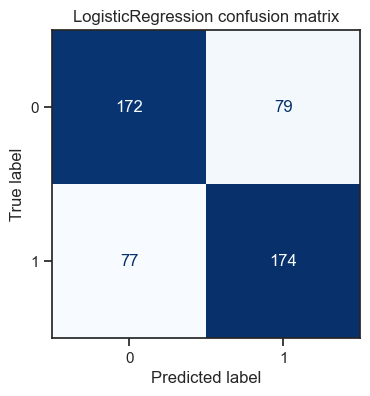

              precision    recall  f1-score   support

           0      0.691     0.685     0.688       251
           1      0.688     0.693     0.690       251

    accuracy                          0.689       502
   macro avg      0.689     0.689     0.689       502
weighted avg      0.689     0.689     0.689       502



,year,current_round,game_id,team,opp_team,seed_num,opp_seed_num,seed_diff,actual,predicted,pred_win
358,2021,64,2021_64_22,Ohio St.,Oral Roberts,2,15,-13,0,1,0.893166
468,2022,64,2022_64_15,Kentucky,Saint Peter's,2,15,-13,0,1,0.893166
202,2012,64,2012_64_7,Duke,Lehigh,2,15,-13,0,1,0.893166
218,2012,64,2012_64_15,Missouri,Norfolk St.,2,15,-13,0,1,0.893166
396,2022,16,2022_16_3,Purdue,Saint Peter's,3,15,-12,0,1,0.876550
338,2021,64,2021_64_12,Texas,Abilene Christian,3,14,-11,0,1,0.857760
10,2011,8,2011_8_2,Kansas,VCU,1,11,-10,0,1,0.836643
260,2021,8,2021_8_1,Michigan,UCLA,1,11,-10,0,1,0.836643
100,2011,64,2011_64_19,Louisville,Morehead St.,4,13,-9,0,1,0.813075
350,2021,64,2021_64_18,Purdue,North Texas,4,13,-9,0,1,0.813075


In [57]:
best_model_name = results.loc[0, "model"]
best_model = fitted_models[best_model_name]
test_pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"{best_model_name} confusion matrix")
plt.show()

print(classification_report(y_test, test_pred, digits=3))

test_view = paired_games.iloc[test_idx].copy().reset_index(drop=True)
test_view["actual"] = y_test.reset_index(drop=True)
test_view["predicted"] = pd.Series(test_pred)
if hasattr(best_model, "predict_proba"):
    test_view["pred_win"] = best_model.predict_proba(X_test)[:, 1]

error_cols = [
    col for col in [
        "year",
        "current_round",
        "game_id",
        "team",
        "opp_team",
        "seed_num",
        "opp_seed_num",
        "seed_diff",
        "actual",
        "predicted",
        "pred_win",
    ] if col in test_view.columns
]

display(
    test_view.loc[test_view["actual"] != test_view["predicted"], error_cols]
    .sort_values("pred_win", ascending=False, na_position="last")
    .head(25)
)


In [58]:
iteration_summary = pd.DataFrame([
    {
        "Iteration": "iter_1",
        "What Changed": "Used the prep module for deterministic matchup assembly and ran a seed-based baseline.",
        "Best Validation Score": results.loc[0, "cv_accuracy_mean"],
        "Test Score": results.loc[0, "test_accuracy"],
        "Keep / Drop Next Time": "Keep the split and prep layer; next add safe pre-game team-strength features.",
    }
])

display(iteration_summary.round({
    "Best Validation Score": 3,
    "Test Score": 3,
}))


,Iteration,What Changed,Best Validation Score,Test Score,Keep / Drop Next Time
0,iter_1,Used the prep module for deterministic matchup...,0.71,0.689,Keep the split and prep layer; next add safe p...
